In [ ]:
# === 📦 Install Required Libraries (Google Colab) ===
!pip install -q langchain faiss-cpu gradio python-dotenv PyPDF2 tiktoken langchain-community
!pip install -q -U langchain-openai langchain-anthropic langchain-google-genai
!pip install -q sentence-transformers pypdf

In [ ]:
# === 🌐 Load Environment Variables ===
import os
from dotenv import load_dotenv

load_dotenv()

# If needed, manually set API keys (for Colab)
os.environ["OPENAI_API_KEY"] = "xxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx"
os.environ["ANTHROPIC_API_KEY"] = "xxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx"
os.environ["GOOGLE_API_KEY"] = "xxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx"

# Confirm keys are loaded
print("✅ OpenAI:", bool(os.getenv("OPENAI_API_KEY")))
print("✅ Anthropic:", bool(os.getenv("ANTHROPIC_API_KEY")))
print("✅ Google:", bool(os.getenv("GOOGLE_API_KEY")))

# === LLM Initialization ===
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI

llm_openai = ChatOpenAI(model="gpt-4o", temperature=0.2)
llm_claude = ChatAnthropic(model="claude-opus-4-6", temperature=0.2) #claude-3-opus-20240229
llm_gemini = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

✅ OpenAI: True
✅ Anthropic: True
✅ Google: True


In [ ]:
# -----------------------------
# Cost analysis instrumentation
# -----------------------------
import tiktoken
from collections import defaultdict

PROMPT_LOG_4CASE = defaultdict(list)
PROMPT_LOG_REPEAT = defaultdict(list)

ACTIVE_PROMPT_LOG = PROMPT_LOG_4CASE
ENABLE_COST_LOGGING = True

# OpenAI exact tokenizer
def _tokcount_openai(text: str, model: str = "gpt-4o") -> int:
    enc = tiktoken.encoding_for_model(model)
    return len(enc.encode(text))

# Claude/Gemini: consistent estimate (note in paper as estimate)
_cl100k = tiktoken.get_encoding("cl100k_base")
def _tokcount_est(text: str) -> int:
    return len(_cl100k.encode(text))

def log_call(
    run_id: str,
    model: str,
    role: str,          # "tool" or "controller" (or "agent" if you insist)
    prompt: str,
    output: str,
    tokens_in: int,
    tokens_out: int,
    note: str = "",
):
    if not ENABLE_COST_LOGGING:
        return
    ACTIVE_PROMPT_LOG[run_id].append({
        "run_id": run_id,
        "model": model,
        "role": role,
        "tokens_in": int(tokens_in),
        "tokens_out": int(tokens_out),
        "note": note,
    })

In [ ]:
# === 🔽 Upload Guideline PDFs (for Colab) ===
from google.colab import files
uploaded = files.upload()  # Upload WHO + MSF PDFs here

# === 🧾 Parse PDFs ===
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Adjust filenames to match what you upload
msf_loader = PyPDFLoader("guideline-170-en-61-113.pdf")
who_loader = PyPDFLoader("TUV_D1_RESPIRATORY GUIDELINES.pdf")

msf_docs = msf_loader.load()
who_docs = who_loader.load()

# Add metadata source tags
for doc in msf_docs:
    doc.metadata["source"] = "MSF"
for doc in who_docs:
    doc.metadata["source"] = "WHO"

all_docs = msf_docs + who_docs
print(f"✅ Loaded {len(msf_docs)} MSF docs, {len(who_docs)} WHO docs")

# === 🔪 Split Text into Chunks for Vector Embedding ===
text_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
chunks = text_splitter.split_documents(all_docs)
print(f"✅ Created {len(chunks)} vector chunks")

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

embedding_model = OpenAIEmbeddings(openai_api_key=os.getenv("OPENAI_API_KEY"))
vectorstore = FAISS.from_documents(chunks, embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Save to local directory
vectorstore.save_local("faiss_guidelines_index")
print("✅ Vectorstore saved to: faiss_guidelines_index")

from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

visit_store = FAISS.from_texts(
    texts=["init"],
    embedding=embedding_model,
    metadatas=[{"patient_id": "__init__", "timestamp": "0"}]
)

# Try removing placeholder doc id if it exists
try:
    visit_store.delete(["0"])
except Exception:
    pass

print("✅ Visit store initialized")

Saving guideline-170-en-61-113.pdf to guideline-170-en-61-113 (1).pdf
Saving TUV_D1_RESPIRATORY GUIDELINES.pdf to TUV_D1_RESPIRATORY GUIDELINES (1).pdf
✅ Loaded 53 MSF docs, 54 WHO docs
✅ Created 311 vector chunks
✅ Vectorstore saved to: faiss_guidelines_index
✅ Visit store initialized


In [ ]:
from langchain_openai import OpenAIEmbeddings

emb = OpenAIEmbeddings()  # same as your code (uses env var)
print("model attribute:", getattr(emb, "model", None))
print("model_name attribute:", getattr(emb, "model_name", None))
print("repr:", emb)

model attribute: text-embedding-ada-002
model_name attribute: None
repr: client=<openai.resources.embeddings.Embeddings object at 0x7b6eb4358b30> async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x7b6eb4358920> model='text-embedding-ada-002' dimensions=None deployment='text-embedding-ada-002' openai_api_version=None openai_api_base=None openai_api_type=None openai_proxy=None embedding_ctx_length=8191 openai_api_key=SecretStr('**********') openai_organization=None allowed_special=None disallowed_special=None chunk_size=1000 max_retries=2 request_timeout=None headers=None tiktoken_enabled=True tiktoken_model_name=None show_progress_bar=False model_kwargs={} skip_empty=False default_headers=None default_query=None retry_min_seconds=4 retry_max_seconds=20 http_client=None http_async_client=None check_embedding_ctx_length=True


In [ ]:
def retrieve_guideline_context(symptoms: str, k: int = 3) -> str:
    """
    Search vector DB for most relevant guideline chunks.
    """
    results = vectorstore.similarity_search(symptoms, k=k)
    seen = set()
    filtered = []

    for doc in results:
        chunk = doc.page_content.strip()
        if chunk and chunk not in seen:
            filtered.append(chunk)
            seen.add(chunk)

    return "\n\n".join(filtered[:3])  # Return top-3 unique chunks


def get_latest_visit_for_patient(patient_id: str, exclude_ts: str | None = None):
    matches = [
        doc for doc in visit_store.docstore._dict.values()
        if doc.metadata.get("patient_id") == patient_id
        and (exclude_ts is None or doc.metadata.get("timestamp") != exclude_ts)
    ]
    if not matches:
        return None

    matches.sort(key=lambda d: d.metadata.get("timestamp", ""), reverse=True)
    return matches[0].page_content


import re
import datetime

def extract_patient_metadata(text: str):
    pid = re.search(r"Patient ID:\s*(\S+)", text)
    vtype = re.search(r"Visit Type:\s*(\S+)", text)
    return (
        pid.group(1).strip() if pid else None,
        vtype.group(1).strip().lower() if vtype else None
    )

def record_visit(patient_id: str, visit_type: str, case_text: str):
    ts = datetime.datetime.utcnow().isoformat()
    doc = Document(
        page_content=case_text,
        metadata={
            "patient_id": patient_id,
            "visit_type": visit_type,
            "timestamp": ts
        }
    )
    visit_store.add_documents([doc])
    return ts

In [ ]:
# === GPT-4o RAG Tool ===
def openai_rag_tool(input_text: str, run_id: str = "unknown") -> str:
    prev_visit = None
    patient_id, visit_type = extract_patient_metadata(input_text)

    original_case_text = input_text

    if visit_type == "follow-up" and patient_id:
        prev_visit = get_latest_visit_for_patient(patient_id)
        if prev_visit:
            input_text = f"""This is a follow-up visit. Compare the current condition with the previous one. Evaluate if symptoms have improved, worsened, or remained unchanged. Adjust the treatment plan accordingly.

== Previous Visit ==
{prev_visit}

== Current Visit ==
{input_text}
"""

    rag = retrieve_guideline_context(input_text)

    prompt = f"""
You are a medical expert following WHO and MSF respiratory guidelines.

{input_text}

== Retrieved Guidelines ==
{rag}

Return a structured response with:
1. Is the condition improving, worsening, or unchanged if it is a follow up? but If this is a new case with no previous data, say: "Not applicable – first recorded visit."
2. Likely Diagnosis
3. Severity Classification
4. Updated Treatment Plan
"""

    response = llm_openai.invoke(prompt).content
    # --- cost logging ---
    log_call(
        run_id=run_id,
        model="gpt-4o",
        role="tool",
        prompt=prompt,
        output=response,
        tokens_in=_tokcount_openai(prompt, "gpt-4o"),
        tokens_out=_tokcount_openai(response, "gpt-4o"),
        note="RAG tool call"
    )
    return response


# === Claude 3 Opus RAG Tool ===
def claude_rag_tool(input_text: str, run_id: str = "unknown") -> str:
    prev_visit = None
    patient_id, visit_type = extract_patient_metadata(input_text)
    original_case_text = input_text


    if visit_type == "follow-up" and patient_id:
        prev_visit = get_latest_visit_for_patient(patient_id)
        if prev_visit:
            input_text = f"""This is a follow-up visit. Compare the patient's condition today with the previous visit. Indicate any changes in symptoms, diagnosis, or severity. If treatment has failed, recommend next steps.

== Previous Visit ==
{prev_visit}

== Current Visit ==
{input_text}
"""

    rag = retrieve_guideline_context(input_text)

    prompt = f"""
You are a medical expert following WHO and MSF respiratory guidelines.

{input_text}

== Retrieved Guidelines ==
{rag}

Return a structured medical opinion:
1. Is the condition improving, worsening, or unchanged if it is a follow up? but If this is a new case with no previous data, say: "Not applicable – first recorded visit."
2. Diagnosis
3. Severity
4. Treatment Plan Adjustments
"""
    out = llm_claude.invoke(prompt).content

    log_call(
        run_id=run_id,
        model="claude-opus-4-6",
        role="tool",
        prompt=prompt,
        output=out,
        tokens_in=_tokcount_est(prompt),
        tokens_out=_tokcount_est(out),
        note="RAG tool call (estimated tokens)"
    )
    return out


# === Gemini 2 Flash RAG Tool ===
def gemini_rag_tool(input_text: str, run_id: str = "unknown") -> str:
    prev_visit = None
    patient_id, visit_type = extract_patient_metadata(input_text)
    original_case_text = input_text

    if visit_type == "follow-up" and patient_id:
        prev_visit = get_latest_visit_for_patient(patient_id)
        if prev_visit:
            input_text = f"""This is a follow-up visit. The patient has received previous treatment. Please compare this visit to the last one and determine if the symptoms are improving. Adjust your diagnosis and treatment plan accordingly.

== Previous Visit ==
{prev_visit}

== Current Visit ==
{input_text}
"""

    rag = retrieve_guideline_context(input_text)

    prompt = f"""
You are a medical expert following WHO and MSF respiratory guidelines.

{input_text}

== Retrieved Guidelines ==
{rag}

Output a structured response:
1. Is the condition improving, worsening, or unchanged if it is a follow up? but If this is a new case with no previous data, say: "Not applicable – first recorded visit."
2. Likely Diagnosis
3. Severity Classification
4. Recommended Treatment Plan
"""
    out = llm_gemini.invoke(prompt).content

    log_call(
        run_id=run_id,
        model="gemini-2.5-flash",
        role="tool",
        prompt=prompt,
        output=out,
        tokens_in=_tokcount_est(prompt),
        tokens_out=_tokcount_est(out),
        note="RAG tool call (estimated tokens)"
    )
    return out

In [ ]:
# === Baseline Tools (no guideline retrieval) ===

def openai_baseline_tool(input_text: str) -> str:
    prompt = f"""
You are a medical expert in respiratory diseases.

{input_text}

Return a structured response with:
1. Is the condition improving, worsening, or unchanged if it is a follow up?
   If this is a new case with no previous data, say: "Not applicable – first recorded visit."
2. Likely Diagnosis
3. Severity Classification
4. Updated Treatment Plan
"""
    return llm_openai.invoke(prompt).content


def claude_baseline_tool(input_text: str) -> str:
    prompt = f"""
You are a medical expert in respiratory diseases.

{input_text}

Return a structured medical opinion:
1. Is the condition improving, worsening, or unchanged if it is a follow up?
   If this is a new case with no previous data, say: "Not applicable – first recorded visit."
2. Diagnosis
3. Severity
4. Treatment Plan Adjustments
"""
    return llm_claude.invoke(prompt).content


def gemini_baseline_tool(input_text: str) -> str:
    prompt = f"""
You are a medical expert in respiratory diseases.

{input_text}

Output a structured response:
1. Is the condition improving, worsening, or unchanged if it is a follow up?
   If this is a new case with no previous data, say: "Not applicable – first recorded visit."
2. Likely Diagnosis
3. Severity Classification
4. Recommended Treatment Plan
"""
    return llm_gemini.invoke(prompt).content

In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.messages import AIMessage  # optional, for safe extraction


# 1) Wrap your existing tool functions

import re
from langchain.tools import tool
from langchain.agents import create_agent

def _infer_run_id(case_text: str) -> str:
    m = re.search(r"Patient ID:\s*([^\s]+)", case_text)
    return m.group(1).strip() if m else "unknown"

@tool("gpt4_respiratory_analyst")
def gpt4_respiratory_analyst(case: str) -> str:
    """WHO/MSF RAG respiratory analysis using GPT-4o."""
    return openai_rag_tool(case, run_id=_infer_run_id(case))

@tool("claude3_respiratory_analyst")
def claude3_respiratory_analyst(case: str) -> str:
    """WHO/MSF RAG respiratory analysis using Claude Opus 4.6."""
    return claude_rag_tool(case, run_id=_infer_run_id(case))

@tool("gemini_respiratory_analyst")
def gemini_respiratory_analyst(case: str) -> str:
    """WHO/MSF RAG respiratory analysis using Gemini 2.5 Flash."""
    return gemini_rag_tool(case, run_id=_infer_run_id(case))

tools = [gpt4_respiratory_analyst, claude3_respiratory_analyst, gemini_respiratory_analyst]

agent = create_agent(
    model=llm_openai,
    tools=tools,
    system_prompt=(
        "You are a medical agent that can call multiple expert respiratory tools "
        "(GPT-4o, Claude Opus 4.6, Gemini 2.5 Flash) based on WHO/MSF guidelines. "
        "Use tools as needed and synthesize a single clinically cautious answer."
    ),
)


def run_agentic_combined_rag_synthesis(
    visit_type, patient_id, age, weight, symptoms, spo2, heart_rate, history
):
    run_id = patient_id  # cost aggregation per case

    case_text = (
        f"Patient ID: {patient_id}\n"
        f"Visit Type: {visit_type}\n"
        f"Age: {age}, Weight: {weight} kg\n"
        f"Symptoms: {symptoms}\n"
        f"SpO₂: {spo2}%, Heart Rate: {heart_rate} bpm\n"
        f"Medical History: {history}"
    )

    # -------------------------
    # 1) Router step (dynamic)
    # -------------------------
    router_prompt = f"""
You are a routing controller. Decide which expert tools to call for this patient case.

Available tools:
- gpt4_respiratory_analyst (GPT-4o RAG)
- claude3_respiratory_analyst (Claude Opus 4.6 RAG)
- gemini_respiratory_analyst (Gemini 2.5 Flash RAG)

Return ONLY a comma-separated list of tool names to call.
Examples:
- gpt4_respiratory_analyst
- gpt4_respiratory_analyst, claude3_respiratory_analyst
- gpt4_respiratory_analyst, claude3_respiratory_analyst, gemini_respiratory_analyst

Rules:
- Call at least ONE tool.
- Prefer 2–3 tools if the case is severe/ambiguous/high-risk.
- If it’s straightforward, 1 tool is acceptable.

== Patient Case ==
{case_text}
""".strip()

    router_out = llm_openai.invoke(router_prompt).content.strip()

    # Log router call as "controller" (since it's GPT-4o overhead)
    log_call(
        run_id=run_id,
        model="gpt-4o",
        role="controller",
        prompt=router_prompt,
        output=router_out,
        tokens_in=_tokcount_openai(router_prompt, "gpt-4o"),
        tokens_out=_tokcount_openai(router_out, "gpt-4o"),
        note="Router decision (dynamic tool selection)"
    )

    # Parse router output safely
    raw = router_out.lower()
    selected = set()

    if "gpt4_respiratory_analyst" in raw:
        selected.add("gpt4_respiratory_analyst")
    if "claude3_respiratory_analyst" in raw:
        selected.add("claude3_respiratory_analyst")
    if "gemini_respiratory_analyst" in raw:
        selected.add("gemini_respiratory_analyst")

    # Fallback: if router output is weird, default to GPT tool (still dynamic-safe)
    if not selected:
        selected = {"gpt4_respiratory_analyst"}

    # -----------------------------------
    # 2) Call selected tools (logged)
    # -----------------------------------
    out_gpt = out_claude = out_gemini = None

    if "gpt4_respiratory_analyst" in selected:
        out_gpt = openai_rag_tool(case_text, run_id=run_id)  # logs as role="tool"

    if "claude3_respiratory_analyst" in selected:
        out_claude = claude_rag_tool(case_text, run_id=run_id)  # logs as role="tool"

    if "gemini_respiratory_analyst" in selected:
        out_gemini = gemini_rag_tool(case_text, run_id=run_id)  # logs as role="tool"

    # -----------------------------------
    # 3) Controller synthesis (logged)
    # -----------------------------------
    synthesis_prompt = f"""
You are the final medical controller.
You have up to three expert opinions (some may be missing if not called).
Synthesize ONE conservative guideline-grounded answer.

Return your final opinion in this exact 4-point format:
1. Condition trend (if follow-up) OR "Not applicable – first recorded visit."
2. Likely Diagnosis
3. Severity Classification
4. Recommended Treatment Plan

== Patient Case ==
{case_text}

== GPT-4o Tool Output ==
{out_gpt if out_gpt else "NOT CALLED"}

== Claude Tool Output ==
{out_claude if out_claude else "NOT CALLED"}

== Gemini Tool Output ==
{out_gemini if out_gemini else "NOT CALLED"}
""".strip()

    final = llm_openai.invoke(synthesis_prompt).content

    log_call(
        run_id=run_id,
        model="gpt-4o",
        role="controller",
        prompt=synthesis_prompt,
        output=final,
        tokens_in=_tokcount_openai(synthesis_prompt, "gpt-4o"),
        tokens_out=_tokcount_openai(final, "gpt-4o"),
        note="Final synthesis (controller)"
    )

    return final

In [ ]:
# === Define the 4 Clinical Test Cases ===
test_cases = [
    {
        "visit_type": "New",
        "patient_id": "P001",
        "age": 6,
        "weight": 22,
        "symptoms": "Severe cough, wheezing, shortness of breath",
        "spo2": 89,
        "heart_rate": 115,
        "history": "Asthma"
    },
    {
        "visit_type": "New",
        "patient_id": "P002",
        "age": 1,
        "weight": 7.5,
        "symptoms": "High fever, cough, rapid breathing",
        "spo2": 88,
        "heart_rate": 140,
        "history": "Malnutrition, recent measles infection"
    },
    {
        "visit_type": "New",
        "patient_id": "P003",
        "age": 9,
        "weight": 30,
        "symptoms": "Intermittent wheezing and cough",
        "spo2": 96,
        "heart_rate": 95,
        "history": "Asthma"
    },
    {
        "visit_type": "New",
        "patient_id": "P004",
        "age": 70,
        "weight": 68,
        "symptoms": "Shortness of breath, chest pain, productive cough",
        "spo2": 86,
        "heart_rate": 105,
        "history": "Hypertension, Type 2 Diabetes"
    }
]

def build_case_prompt(case):
    return (
        f"Patient ID: {case['patient_id']}\n"
        f"Visit Type: {case['visit_type']}\n"
        f"Age: {case['age']}, Weight: {case['weight']} kg\n"
        f"Symptoms: {case['symptoms']}\n"
        f"SpO₂: {case['spo2']}%, Heart Rate: {case['heart_rate']} bpm\n"
        f"Medical History: {case['history']}"
    )

In [ ]:
# === Alignment utilities (cosine similarity with all-MiniLM-L6-v2) ===
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

#alignment_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
alignment_model = SentenceTransformer("all-MiniLM-L6-v2")

def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def semantic_similarity(text1: str, text2: str) -> float:
    if not text1 or not text2:
        return 0.0
    a = alignment_model.encode(text1, convert_to_numpy=True)
    b = alignment_model.encode(text2, convert_to_numpy=True)
    return cosine_similarity(a, b)


def get_alignment_score(system_output: str, reference_answer: str) -> float:
    emb_sys = alignment_model.encode(system_output, convert_to_numpy=True)
    emb_ref = alignment_model.encode(reference_answer, convert_to_numpy=True)
    return cosine_similarity(emb_sys, emb_ref)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# === Reference guideline-aligned answers for each case ===
# Replace these with your curated guideline-based reference answers.
reference_answers = {
    "P001": """
Diagnosis: Acute severe asthma attack in a 6-year-old child with hypoxemia (SpO₂ 89%) and tachycardia.

Severity classification: Severe asthma exacerbation (SpO₂ < 90%, marked respiratory distress).

Recommended management:
Administer oxygen via face mask to maintain SpO₂ between 94% and 98%.
Give salbutamol 5 mg by nebulizer (child >5 years) and repeat every 30 minutes if necessary or continuously in severe asthma.
Add ipratropium bromide 0.25 mg by nebulizer every 4 hours in severe cases.
Administer systemic corticosteroids early: hydrocortisone 1–4 mg/kg IV (maximum 200 mg) or prednisolone 1 mg/kg orally.
Monitor heart rate, respiratory rate, SpO₂, and signs of fatigue.
Hospital admission is required for ongoing monitoring and escalation if no improvement.
""",

    "P002": """
Diagnosis: Severe pneumonia in a 1-year-old infant with hypoxemia (SpO₂ 88%) and risk factors (malnutrition, recent measles).

Severity classification: Severe pneumonia with hypoxia in a high-risk child under 5 years.

Recommended management:
Hospitalize and administer oxygen continuously to maintain SpO₂ ≥ 94%.
Start appropriate parenteral antibiotics according to severe pneumonia guidelines (e.g., IV ampicillin or ceftriaxone where indicated).
Provide supportive care including IV fluids if unable to drink, antipyretics for fever, and careful nutritional support.
Monitor closely for respiratory distress, sepsis, or treatment failure.
Escalate care if no improvement within 48 hours.
""",

    "P003": """
Diagnosis: Mild asthma exacerbation in a 9-year-old child with intermittent wheeze and normal oxygen saturation (SpO₂ 96%).

Severity classification: Mild asthma attack (no hypoxemia, mild tachycardia).

Recommended management:
No oxygen required as SpO₂ is within normal range.
Administer inhaled salbutamol via MDI with spacer (4–10 puffs as needed).
Systemic corticosteroids are not routinely required unless symptoms worsen.
Review inhaler technique and reinforce asthma action plan.
Provide follow-up assessment and consider preventive therapy (e.g., inhaled corticosteroids) if symptoms are recurrent.
""",

   "P004": """
Diagnosis: Severe community-acquired pneumonia in a 70-year-old adult with hypoxemia (SpO₂ 86%) and comorbidities.

Severity classification: Severe pneumonia with hypoxia.

Recommended management:
Hospitalize immediately and administer oxygen via face mask to maintain SpO₂ between 94% and 98%.
Initiate empiric IV antibiotic therapy appropriate for severe community-acquired pneumonia (e.g., ceftriaxone-based regimen per protocol).
Monitor for respiratory failure, sepsis, and hemodynamic instability.
Provide IV fluids cautiously and manage comorbid conditions.
Regular reassessment is required to evaluate response and adjust therapy.
""",
}

In [ ]:
import pandas as pd

alignment_rows = []

# Cost logs ONLY for the agentic pipeline of the 4-case experiment
ACTIVE_PROMPT_LOG = PROMPT_LOG_4CASE
PROMPT_LOG_4CASE.clear()

FOUR_CASE_IDS = {"P001", "P002", "P003", "P004"}

for case in test_cases:
    pid = case["patient_id"]
    if pid not in FOUR_CASE_IDS:
        continue

    case_prompt = build_case_prompt(case)
    ref = reference_answers[pid]

    # 1) Baseline (alignment only — NOT cost logged)
    gpt_base_out = openai_baseline_tool(case_prompt)
    claude_base_out = claude_baseline_tool(case_prompt)
    gemini_base_out = gemini_baseline_tool(case_prompt)

    # 2) RAG (alignment only — explicitly disable cost logging here)
    ENABLE_COST_LOGGING = False
    gpt_rag_out = openai_rag_tool(case_prompt, run_id=pid)
    claude_rag_out = claude_rag_tool(case_prompt, run_id=pid)
    gemini_rag_out = gemini_rag_tool(case_prompt, run_id=pid)
    ENABLE_COST_LOGGING = True

    # 3) Agentic pipeline (✅ cost logged: dynamic tools used + controller)
    agentic_out = run_agentic_combined_rag_synthesis(
        case["visit_type"],
        case["patient_id"],
        case["age"],
        case["weight"],
        case["symptoms"],
        case["spo2"],
        case["heart_rate"],
        case["history"]
    )

    alignment_rows.extend([
        {"Patient ID": pid, "Case": pid, "Model": "GPT-4o",              "Config": "Baseline", "Alignment (cosine)": get_alignment_score(gpt_base_out, ref)},
        {"Patient ID": pid, "Case": pid, "Model": "GPT-4o",              "Config": "RAG",      "Alignment (cosine)": get_alignment_score(gpt_rag_out, ref)},
        {"Patient ID": pid, "Case": pid, "Model": "Claude Opus 4.6",     "Config": "Baseline", "Alignment (cosine)": get_alignment_score(claude_base_out, ref)},
        {"Patient ID": pid, "Case": pid, "Model": "Claude Opus 4.6",     "Config": "RAG",      "Alignment (cosine)": get_alignment_score(claude_rag_out, ref)},
        {"Patient ID": pid, "Case": pid, "Model": "Gemini 2.5 Flash",    "Config": "Baseline", "Alignment (cosine)": get_alignment_score(gemini_base_out, ref)},
        {"Patient ID": pid, "Case": pid, "Model": "Gemini 2.5 Flash",    "Config": "RAG",      "Alignment (cosine)": get_alignment_score(gemini_rag_out, ref)},
        {"Patient ID": pid, "Case": pid, "Model": "Agentic Pipeline",    "Config": "Agentic",  "Alignment (cosine)": get_alignment_score(agentic_out, ref)},
    ])

alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)
alignment_df.to_csv("alignment_scores_per_case.csv", index=False)

print("✅ 4-case alignment saved: alignment_scores_per_case.csv")
print("✅ PROMPT_LOG_4CASE contains ONLY *agentic pipeline* token logs (dynamic tools + controller).")

,Patient ID,Case,Model,Config,Alignment (cosine)
0,P001,P001,GPT-4o,Baseline,0.800517
1,P001,P001,GPT-4o,RAG,0.765048
2,P001,P001,Claude Opus 4.6,Baseline,0.632453
3,P001,P001,Claude Opus 4.6,RAG,0.681264
4,P001,P001,Gemini 2.5 Flash,Baseline,0.741216
5,P001,P001,Gemini 2.5 Flash,RAG,0.686950
6,P001,P001,Agentic Pipeline,Agentic,0.818802
7,P002,P002,GPT-4o,Baseline,0.743044
8,P002,P002,GPT-4o,RAG,0.729540
9,P002,P002,Claude Opus 4.6,Baseline,0.643158


✅ 4-case alignment saved: alignment_scores_per_case.csv
✅ PROMPT_LOG_4CASE contains ONLY *agentic pipeline* token logs (dynamic tools + controller).


In [ ]:
import pprint
pprint.pp(PROMPT_LOG_4CASE["P001"][:2])

[{'run_id': 'P001',
  'model': 'gpt-4o',
  'role': 'controller',
  'tokens_in': 252,
  'tokens_out': 28,
  'note': 'Router decision (dynamic tool selection)'},
 {'run_id': 'P001',
  'model': 'gpt-4o',
  'role': 'tool',
  'tokens_in': 601,
  'tokens_out': 302,
  'note': 'RAG tool call'}]


In [ ]:
for pid in ["P001","P002","P003","P004"]:
    print(pid, "log entries =", len(PROMPT_LOG_4CASE[pid]),
          "| roles =", sorted(set(x["role"] for x in PROMPT_LOG_4CASE[pid])),
          "| models =", sorted(set(x["model"] for x in PROMPT_LOG_4CASE[pid])))

P001 log entries = 5 | roles = ['controller', 'tool'] | models = ['claude-opus-4-6', 'gemini-2.5-flash', 'gpt-4o']
P002 log entries = 5 | roles = ['controller', 'tool'] | models = ['claude-opus-4-6', 'gemini-2.5-flash', 'gpt-4o']
P003 log entries = 4 | roles = ['controller', 'tool'] | models = ['claude-opus-4-6', 'gpt-4o']
P004 log entries = 5 | roles = ['controller', 'tool'] | models = ['claude-opus-4-6', 'gemini-2.5-flash', 'gpt-4o']


In [ ]:
alignment_summary_df = (
    alignment_df
    .groupby(["Model", "Config"])["Alignment (cosine)"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "Mean Alignment", "std": "Std Alignment"})
)

display(alignment_summary_df)

alignment_summary_df.to_csv("alignment_summary_baseline_rag_agentic.csv", index=False)

,Model,Config,Mean Alignment,Std Alignment
0,Agentic Pipeline,Agentic,0.793477,0.066888
1,Claude Opus 4.6,Baseline,0.696284,0.071397
2,Claude Opus 4.6,RAG,0.694456,0.047219
3,GPT-4o,Baseline,0.724677,0.078747
4,GPT-4o,RAG,0.755410,0.065880
5,Gemini 2.5 Flash,Baseline,0.732964,0.049091
6,Gemini 2.5 Flash,RAG,0.685628,0.088742


**Plots**

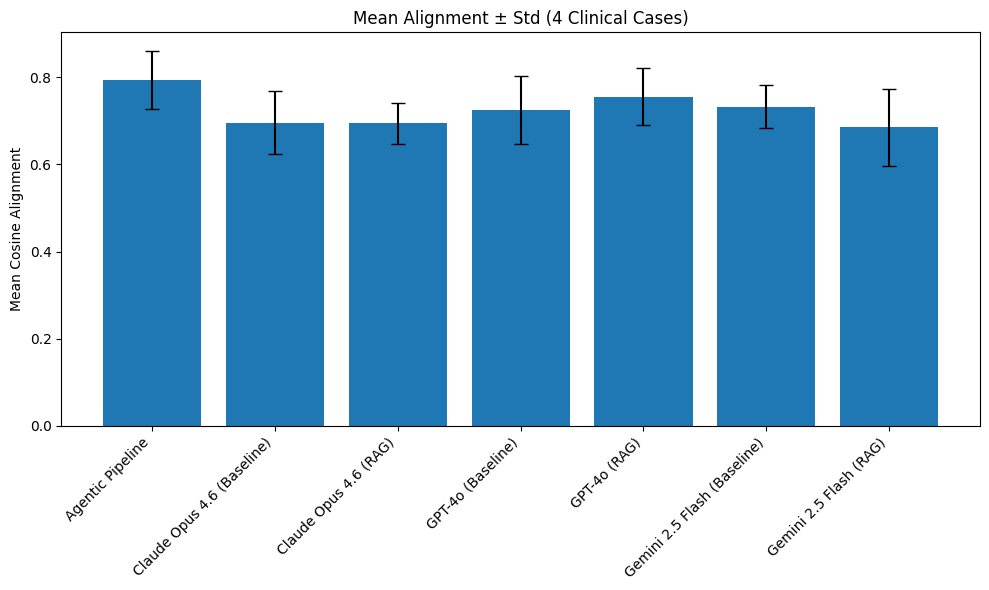

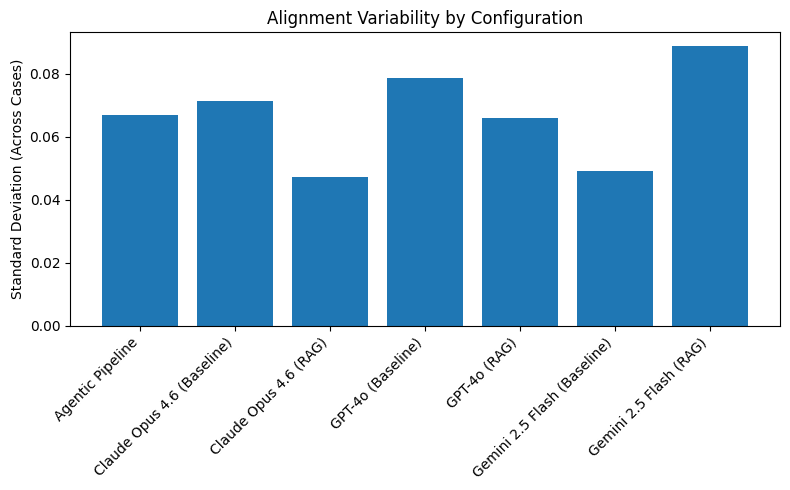

In [ ]:
import matplotlib.pyplot as plt

df_plot = alignment_summary_df.copy()

df_plot["Display Label"] = df_plot["Model"] + " (" + df_plot["Config"] + ")"
df_plot.loc[df_plot["Config"].str.lower() == "agentic", "Display Label"] = "Agentic Pipeline"
# (optional) if you want it even shorter:
# df_plot.loc[df_plot["Config"].str.lower() == "agentic", "Display Label"] = "Agentic"

labels = df_plot["Display Label"]
means = df_plot["Mean Alignment"]
stds  = df_plot["Std Alignment"]

plt.figure(figsize=(10,6))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Cosine Alignment")
plt.title("Mean Alignment ± Std (4 Clinical Cases)")
plt.tight_layout()
plt.savefig("alignment_std.pdf")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(labels, stds)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Standard Deviation (Across Cases)")
plt.title("Alignment Variability by Configuration")
plt.tight_layout()
plt.savefig("alignment_variability.pdf")
plt.show()

# Repeatability Test

In [ ]:
ENABLE_COST_LOGGING = True

In [ ]:
import numpy as np
import pandas as pd

# ✅ Cost logs ONLY for repeatability experiment
ACTIVE_PROMPT_LOG = PROMPT_LOG_REPEAT
PROMPT_LOG_REPEAT.clear()

repeat_case = {
    "visit_type": "New",
    "patient_id": "repeat-1",
    "age": 12,
    "weight": 35,
    "symptoms": "Fever, cough, wheezing",
    "spo2": 93,
    "heart_rate": 105,
    "history": "Asthma"
}

reference_answer_repeat = """
Diagnosis: Acute asthma exacerbation, likely triggered by an acute respiratory infection (given fever and cough).

Severity: Moderate to severe asthma exacerbation. This is supported by the presence of wheeze, cough, a history of asthma,
SpO₂ around 93% (mild hypoxia), and tachycardia.

Treatment:
- Give rapid-acting inhaled bronchodilator (e.g., salbutamol via MDI with spacer or nebuliser, repeated in the first hour),
- Start systemic corticosteroids (e.g., oral prednisolone 1–2 mg/kg up to recommended max dose),
- Give oxygen to maintain SpO₂ ≥ 94%,
- Monitor closely for clinical improvement; escalate care (e.g., IV therapy, ICU referral) if the child does not respond.
""".strip()

n_runs = 30
repeat_alignment_scores = []

for i in range(n_runs):
    print(f"--- Run {i+1}/{n_runs} ---")
    output = run_agentic_combined_rag_synthesis(
        visit_type=repeat_case["visit_type"],
        patient_id=repeat_case["patient_id"],
        age=repeat_case["age"],
        weight=repeat_case["weight"],
        symptoms=repeat_case["symptoms"],
        spo2=repeat_case["spo2"],
        heart_rate=repeat_case["heart_rate"],
        history=repeat_case["history"]
    )

    score = semantic_similarity(output, reference_answer_repeat)
    repeat_alignment_scores.append(score)
    print(f"Alignment (cosine): {score:.4f}\n")

scores_arr = np.array(repeat_alignment_scores)

mean_alignment = float(scores_arr.mean())
std_alignment  = float(scores_arr.std())
min_alignment  = float(scores_arr.min())
max_alignment  = float(scores_arr.max())
cv_alignment   = float(std_alignment / mean_alignment) if mean_alignment != 0 else None
ci_low         = float(mean_alignment - 1.96 * std_alignment)
ci_high        = float(mean_alignment + 1.96 * std_alignment)

summary = pd.DataFrame([{
    "n_runs": n_runs,
    "mean_alignment": mean_alignment,
    "std_alignment": std_alignment,
    "min_alignment": min_alignment,
    "max_alignment": max_alignment,
    "cv_alignment": cv_alignment,
    "ci_low_95": ci_low,
    "ci_high_95": ci_high
}])

summary.to_csv("repeatability_30runs_summary.csv", index=False)

print("Repeatability alignment statistics:")
for k, v in summary.iloc[0].items():
    print(f"  {k}: {v}")

display(summary)

print("✅ PROMPT_LOG_REPEAT contains ONLY repeatability agent/controller + any tool calls used in those runs.")

--- Run 1/30 ---
Alignment (cosine): 0.8711

--- Run 2/30 ---
Alignment (cosine): 0.8422

--- Run 3/30 ---
Alignment (cosine): 0.8374

--- Run 4/30 ---
Alignment (cosine): 0.8233

--- Run 5/30 ---
Alignment (cosine): 0.8635

--- Run 6/30 ---
Alignment (cosine): 0.8276

--- Run 7/30 ---
Alignment (cosine): 0.8245

--- Run 8/30 ---
Alignment (cosine): 0.8316

--- Run 9/30 ---
Alignment (cosine): 0.8320

--- Run 10/30 ---
Alignment (cosine): 0.8488

--- Run 11/30 ---
Alignment (cosine): 0.8501

--- Run 12/30 ---
Alignment (cosine): 0.8809

--- Run 13/30 ---
Alignment (cosine): 0.8635

--- Run 14/30 ---
Alignment (cosine): 0.8318

--- Run 15/30 ---
Alignment (cosine): 0.8406

--- Run 16/30 ---
Alignment (cosine): 0.8269

--- Run 17/30 ---
Alignment (cosine): 0.8170

--- Run 18/30 ---
Alignment (cosine): 0.8427

--- Run 19/30 ---
Alignment (cosine): 0.8565

--- Run 20/30 ---
Alignment (cosine): 0.8560

--- Run 21/30 ---
Alignment (cosine): 0.8665

--- Run 22/30 ---
Alignment (cosine): 0.819

,n_runs,mean_alignment,std_alignment,min_alignment,max_alignment,cv_alignment,ci_low_95,ci_high_95
0,30,0.843755,0.023397,0.779109,0.880943,0.02773,0.797897,0.889614


✅ PROMPT_LOG_REPEAT contains ONLY repeatability agent/controller + any tool calls used in those runs.


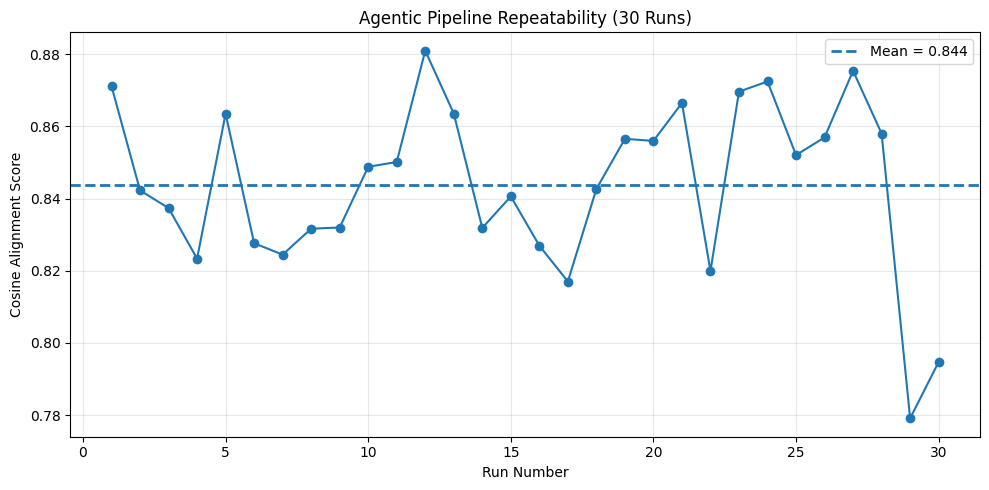

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

scores_arr = np.array(repeat_alignment_scores)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(scores_arr)+1), scores_arr, marker='o')
plt.axhline(scores_arr.mean(), linestyle='--', linewidth=2, label=f"Mean = {scores_arr.mean():.3f}")

plt.title("Agentic Pipeline Repeatability (30 Runs)")
plt.xlabel("Run Number")
plt.ylabel("Cosine Alignment Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("repeatability_line.pdf")
plt.show()

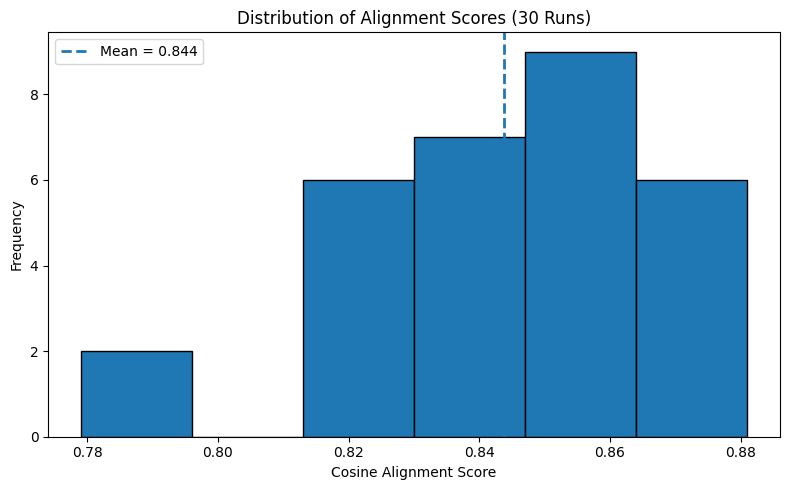

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(scores_arr, bins=6, edgecolor='black')
plt.axvline(scores_arr.mean(), linestyle='--', linewidth=2, label=f"Mean = {scores_arr.mean():.3f}")

plt.title("Distribution of Alignment Scores (30 Runs)")
plt.xlabel("Cosine Alignment Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("repeatability_dist.pdf")
plt.show()

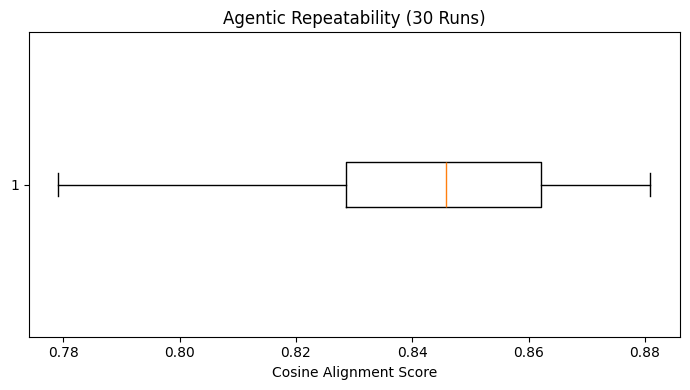

In [ ]:
plt.figure(figsize=(7,4))
plt.boxplot(scores_arr, vert=False)
plt.title("Agentic Repeatability (30 Runs)")
plt.xlabel("Cosine Alignment Score")
plt.tight_layout()
plt.savefig("repeatability_box.pdf")
plt.show()

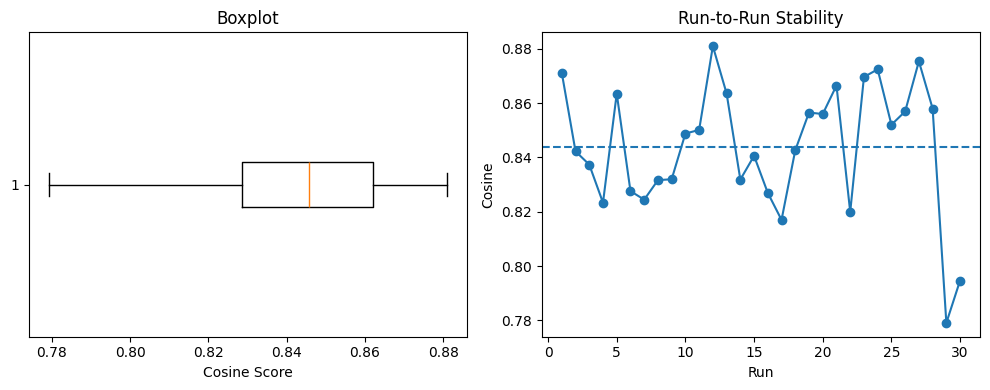

In [ ]:
plt.figure(figsize=(10,4))

# Left: Boxplot
plt.subplot(1,2,1)
plt.boxplot(scores_arr, vert=False)
plt.title("Boxplot")
plt.xlabel("Cosine Score")

# Right: Line Plot
plt.subplot(1,2,2)
plt.plot(range(1,len(scores_arr)+1), scores_arr, marker='o')
plt.axhline(scores_arr.mean(), linestyle='--')
plt.title("Run-to-Run Stability")
plt.xlabel("Run")
plt.ylabel("Cosine")

plt.tight_layout()
plt.savefig("repeatability_all.pdf")
plt.show()

# Cost Analysis

**4-case cost only**

In [ ]:
import pandas as pd

# Pricing per 1M tokens (USD)
PRICING_PER_1M = {
    "gpt-4o": {"in": 2.50, "out": 10.00},
    "claude-opus-4-6": {"in": 5.00, "out": 25.00},
    "gemini-2.5-flash": {"in": 0.30, "out": 2.50},
}

def cost_from_tokens(model: str, tokens_in: int, tokens_out: int) -> float:
    p = PRICING_PER_1M[model]
    return (tokens_in / 1_000_000) * p["in"] + (tokens_out / 1_000_000) * p["out"]

LOG = PROMPT_LOG_4CASE

MODEL_LABEL = {
    "gpt-4o": "GPT-4o",
    "claude-opus-4-6": "Claude Opus 4.6",
    "gemini-2.5-flash": "Gemini 2.5 Flash",
}

TOOL_MODELS = ["gpt-4o", "claude-opus-4-6", "gemini-2.5-flash"]

rows = []
for run_id in sorted(LOG.keys()):
    calls = LOG[run_id]

    # Initialize zero buckets so Table 9 always has consistent columns
    per_tool = {m: {"in": 0, "out": 0, "cost": 0.0} for m in TOOL_MODELS}
    controller = {"in": 0, "out": 0, "cost": 0.0}
    used_tools = set()
    total_cost = 0.0

    for c in calls:
        m = c["model"]
        role = c.get("role", "")
        tin = int(c["tokens_in"])
        tout = int(c["tokens_out"])
        ccost = cost_from_tokens(m, tin, tout)

        if role == "tool" and m in per_tool:
            per_tool[m]["in"] += tin
            per_tool[m]["out"] += tout
            per_tool[m]["cost"] += ccost
            total_cost += ccost
            used_tools.add(m)

        elif role == "controller" and m == "gpt-4o":
            controller["in"] += tin
            controller["out"] += tout
            controller["cost"] += ccost
            total_cost += ccost

    rows.append({
        "Case": run_id,
        "Tools Used": ", ".join(MODEL_LABEL[m] for m in sorted(used_tools)) if used_tools else "None",
        "GPT-4o Tool Input": per_tool["gpt-4o"]["in"],
        "GPT-4o Tool Output": per_tool["gpt-4o"]["out"],
        "GPT-4o Tool Cost (USD)": per_tool["gpt-4o"]["cost"],

        "Claude Tool Input (est)": per_tool["claude-opus-4-6"]["in"],
        "Claude Tool Output (est)": per_tool["claude-opus-4-6"]["out"],
        "Claude Tool Cost (USD)": per_tool["claude-opus-4-6"]["cost"],

        "Gemini Tool Input (est)": per_tool["gemini-2.5-flash"]["in"],
        "Gemini Tool Output (est)": per_tool["gemini-2.5-flash"]["out"],
        "Gemini Tool Cost (USD)": per_tool["gemini-2.5-flash"]["cost"],

        "Controller (GPT-4o) Input": controller["in"],
        "Controller (GPT-4o) Output": controller["out"],
        "Controller (GPT-4o) Cost (USD)": controller["cost"],

        "Total Cost (USD)": total_cost,
    })

df_table9 = pd.DataFrame(rows)

# Round cost columns for paper/table
for col in [c for c in df_table9.columns if "Cost" in c]:
    df_table9[col] = df_table9[col].astype(float).round(6)

display(df_table9)
df_table9.to_csv("table9_dynamic_cost_breakdown.csv", index=False)
print("✅ Saved: table9_dynamic_cost_breakdown.csv")

,Case,Tools Used,GPT-4o Tool Input,GPT-4o Tool Output,GPT-4o Tool Cost (USD),Claude Tool Input (est),Claude Tool Output (est),Claude Tool Cost (USD),Gemini Tool Input (est),Gemini Tool Output (est),Gemini Tool Cost (USD),Controller (GPT-4o) Input,Controller (GPT-4o) Output,Controller (GPT-4o) Cost (USD),Total Cost (USD)
0,P001,"Claude Opus 4.6, Gemini 2.5 Flash, GPT-4o",601,302,0.004523,618,1043,0.029165,618,444,0.001295,2145,324,0.008602,0.043585
1,P002,"Claude Opus 4.6, Gemini 2.5 Flash, GPT-4o",630,217,0.003745,646,1127,0.031405,646,306,0.000959,2027,359,0.008658,0.044766
2,P003,"Claude Opus 4.6, GPT-4o",598,296,0.004455,615,856,0.024475,0,0,0.000000,1542,397,0.007825,0.036755
3,P004,"Claude Opus 4.6, Gemini 2.5 Flash, GPT-4o",579,362,0.005068,596,1310,0.035730,596,556,0.001569,2608,465,0.011170,0.053536


✅ Saved: table9_dynamic_cost_breakdown.csv


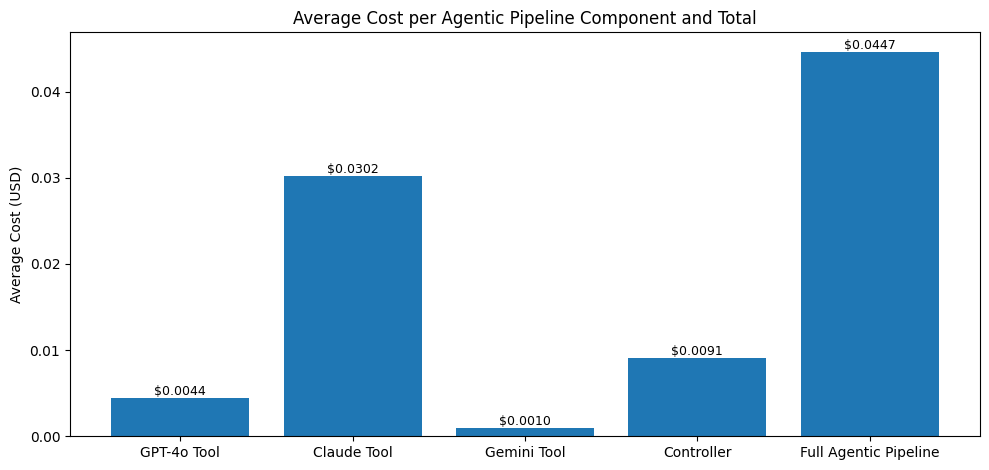

Saved: agentic_cost_avg_dynamic.png
Average total cost per case: 0.04466


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- sanity: ensure df_table9 exists ---
required_cols = [
    "GPT-4o Tool Cost (USD)",
    "Claude Tool Cost (USD)",
    "Gemini Tool Cost (USD)",
    "Controller (GPT-4o) Cost (USD)",
    "Total Cost (USD)",
]
missing = [c for c in required_cols if c not in df_table9.columns]
if missing:
    raise ValueError(f"df_table9 missing columns: {missing}\nAvailable: {list(df_table9.columns)}")

# --- compute averages across the 4 cases ---
avg_gpt_tool = float(df_table9["GPT-4o Tool Cost (USD)"].mean())
avg_claude   = float(df_table9["Claude Tool Cost (USD)"].mean())
avg_gemini   = float(df_table9["Gemini Tool Cost (USD)"].mean())
avg_ctrl     = float(df_table9["Controller (GPT-4o) Cost (USD)"].mean())
avg_total    = float(df_table9["Total Cost (USD)"].mean())

labels = ["GPT-4o Tool", "Claude Tool", "Gemini Tool", "Controller", "Full Agentic Pipeline"]
values = [avg_gpt_tool, avg_claude, avg_gemini, avg_ctrl, avg_total]

plt.figure(figsize=(10, 4.8))
bars = plt.bar(labels, values)

# value labels on bars
for b, v in zip(bars, values):
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"${v:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylabel("Average Cost (USD)")
plt.title("Average Cost per Agentic Pipeline Component and Total")

# NOTE: caption text belongs in LaTeX, but you can keep the title here.
# If you want the plot itself to carry the 'dynamic' note:
# plt.suptitle("Dynamic tool selection (up to 3 tools) + 1 controller", y=0.98, fontsize=9)

plt.tight_layout()
plt.savefig("agentic_cost_avg_dynamic.png", dpi=300)
plt.show()

print("Saved: agentic_cost_avg_dynamic.png")
print("Average total cost per case:", round(avg_total, 6))

**Repeatability cost only [Not need because each run wasn't saved uniquely]**

In [ ]:
import pandas as pd

PRICING_PER_1M = {
    "gpt-4o": {"in": 2.50, "out": 10.00},
    "claude-opus-4-6": {"in": 5.00, "out": 25.00},
    "gemini-2.5-flash": {"in": 0.30, "out": 2.50},
}

def cost_from_tokens(model: str, tokens_in: int, tokens_out: int) -> float:
    p = PRICING_PER_1M[model]
    return (tokens_in / 1_000_000) * p["in"] + (tokens_out / 1_000_000) * p["out"]

LOG = PROMPT_LOG_REPEAT

rows = []
for run_id, calls in LOG.items():
    per_model = {}
    total = 0.0

    for c in calls:
        m = c["model"]
        tin, tout = int(c["tokens_in"]), int(c["tokens_out"])

        per_model.setdefault(m, {"in": 0, "out": 0, "cost": 0.0})
        per_model[m]["in"] += tin
        per_model[m]["out"] += tout

        c_cost = cost_from_tokens(m, tin, tout)
        per_model[m]["cost"] += c_cost
        total += c_cost

    rows.append({
        "run_id": run_id,
        "gpt-4o_in": per_model.get("gpt-4o", {}).get("in", 0),
        "gpt-4o_out": per_model.get("gpt-4o", {}).get("out", 0),
        "claude_in_est": per_model.get("claude-opus-4-6", {}).get("in", 0),
        "claude_out_est": per_model.get("claude-opus-4-6", {}).get("out", 0),
        "gemini_in_est": per_model.get("gemini-2.5-flash", {}).get("in", 0),
        "gemini_out_est": per_model.get("gemini-2.5-flash", {}).get("out", 0),
        "total_cost": total,
    })

df_cost_repeat = pd.DataFrame(rows).sort_values("run_id")
df_cost_repeat["total_cost"] = df_cost_repeat["total_cost"].round(6)

display(df_cost_repeat)

print("Average cost per repeatability run_id:", round(df_cost_repeat["total_cost"].mean(), 6))
print("Total cost (repeatability):", round(df_cost_repeat["total_cost"].sum(), 6))

df_cost_repeat.to_csv("cost_repeatability.csv", index=False)
print("Saved: cost_repeatability.csv")

,run_id,gpt-4o_in,gpt-4o_out,claude_in_est,claude_out_est,gemini_in_est,gemini_out_est,total_cost
0,repeat-1,83178,20366,18420,31766,18420,14042,1.338486


Average cost per repeatability run_id: 1.338486
Total cost (repeatability): 1.338486
Saved: cost_repeatability.csv


In [ ]:
import json
with open("prompt_log_4case.json","w") as f:
    json.dump(PROMPT_LOG_4CASE, f)